# e스포츠의 스포츠성 분석
## e스포츠 vs 전통 스포츠 선수의 생체 데이터 비교

**목적**: e스포츠 선수의 경기 중 신체적·생리학적 반응이 전통 스포츠 선수와 동등한 수준임을 데이터로 입증

**분석 파이프라인**:
1. 데이터 로딩 및 전처리
2. 임계값 돌파 분석 (The Threshold)
3. 시계열 패턴 분석 (Temporal Dynamics)
4. 상관관계 분석 (Convergence)
5. 동등성 검증 (Equivalence)
6. 종합 결론

In [25]:
# 필요 라이브러리 설치 (필요 시)
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn plotly

In [26]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os
import json
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("라이브러리 로딩 완료!")

라이브러리 로딩 완료!


---
## 1. 데이터 로딩 및 전처리

In [27]:
# 경로 설정
BASE_PATH = '/Volumes/Samsung_T5/00_work_out/02_ing/pase3_mini_project/esports/data'
ESPORTS_PATH = os.path.join(BASE_PATH, 'eSports_Sensors_Dataset-master')
OUTPUT_PATH = '/Volumes/Samsung_T5/00_work_out/02_ing/pase3_mini_project/esports/medical/output'

# 출력 폴더 생성
os.makedirs(OUTPUT_PATH, exist_ok=True)

### 1.1 e스포츠 센서 데이터 로딩

In [28]:
def load_esports_data(esports_path):
    """
    e스포츠 센서 데이터를 로딩하고 통합합니다.
    """
    # 플레이어 정보 로딩
    players_info = pd.read_csv(os.path.join(esports_path, 'players_info.csv'))
    print("플레이어 정보:")
    display(players_info)
    
    matches_path = os.path.join(esports_path, 'matches')
    all_hr_data = []
    all_gsr_data = []
    match_summaries = []
    
    # 각 매치 순회
    for match_folder in sorted(os.listdir(matches_path)):
        if not match_folder.startswith('match_'):
            continue
            
        match_path = os.path.join(matches_path, match_folder)
        
        # 매치 메타 정보 로딩
        meta_path = os.path.join(match_path, 'meta_info.json')
        if os.path.exists(meta_path):
            with open(meta_path, 'r') as f:
                meta_info = json.load(f)
        else:
            meta_info = {}
        
        team = meta_info.get('team', 'unknown')
        match_duration = meta_info.get('match_duration', 0)
        
        # 각 플레이어 데이터 로딩
        for player_folder in os.listdir(match_path):
            if not player_folder.startswith('player_'):
                continue
                
            player_path = os.path.join(match_path, player_folder)
            player_id = int(player_folder.split('_')[1])
            
            # 심박수 데이터
            hr_path = os.path.join(player_path, 'heart_rate.csv')
            if os.path.exists(hr_path):
                hr_df = pd.read_csv(hr_path)
                hr_df['match'] = match_folder
                hr_df['player_id'] = player_id
                hr_df['team'] = team
                hr_df['match_duration'] = match_duration
                all_hr_data.append(hr_df)
            
            # GSR 데이터
            gsr_path = os.path.join(player_path, 'gsr.csv')
            if os.path.exists(gsr_path):
                gsr_df = pd.read_csv(gsr_path)
                gsr_df['match'] = match_folder
                gsr_df['player_id'] = player_id
                gsr_df['team'] = team
                all_gsr_data.append(gsr_df)
        
        match_summaries.append({
            'match': match_folder,
            'team': team,
            'duration': match_duration
        })
    
    # 데이터프레임 통합
    hr_combined = pd.concat(all_hr_data, ignore_index=True)
    gsr_combined = pd.concat(all_gsr_data, ignore_index=True)
    match_summary_df = pd.DataFrame(match_summaries)
    
    return hr_combined, gsr_combined, match_summary_df, players_info

# e스포츠 데이터 로딩
esports_hr, esports_gsr, match_summary, players_info = load_esports_data(ESPORTS_PATH)

print(f"\ne스포츠 심박수 데이터: {len(esports_hr):,} 레코드")
print(f"e스포츠 GSR 데이터: {len(esports_gsr):,} 레코드")
print(f"총 매치 수: {len(match_summary)}")

플레이어 정보:


,player_id,team,hours_played,best_rank_achieved,rank_season_9,dominant_hand
0,0,amateurs,336,gold,gold,right
1,1,amateurs,1200,gold,gold,right
2,2,amateurs,1000,platinum,platinum,right
3,3,amateurs,400,no_rank,no_rank,right
4,4,amateurs,415,gold,gold,right
5,0,pros,5000,diamond,diamond,left
6,1,pros,6000,diamond,diamond,right
7,2,pros,5000,diamond,diamond,right
8,3,pros,10000,master,master,right
9,4,pros,7000,diamond,diamond,right



e스포츠 심박수 데이터: 128,035 레코드
e스포츠 GSR 데이터: 149,649 레코드
총 매치 수: 22


In [29]:
# e스포츠 데이터 미리보기
print("=== e스포츠 심박수 데이터 ====")
display(esports_hr.head(10))
print(f"\n심박수 범위: {esports_hr['heart_rate'].min():.1f} ~ {esports_hr['heart_rate'].max():.1f} BPM")
print(f"평균 심박수: {esports_hr['heart_rate'].mean():.1f} BPM")

=== e스포츠 심박수 데이터 ====


,time,heart_rate,match,player_id,team,match_duration
0,0.0,102.000000,match_0,0,amateurs,957
1,1.0,101.333333,match_0,0,amateurs,957
2,2.0,100.571429,match_0,0,amateurs,957
3,3.0,99.200000,match_0,0,amateurs,957
4,4.0,98.064516,match_0,0,amateurs,957
5,5.0,96.935484,match_0,0,amateurs,957
6,6.0,95.354839,match_0,0,amateurs,957
7,7.0,93.548387,match_0,0,amateurs,957
8,8.0,92.161290,match_0,0,amateurs,957
9,9.0,91.483871,match_0,0,amateurs,957



심박수 범위: 0.0 ~ 163.0 BPM
평균 심박수: 82.5 BPM


### 1.2 전통 스포츠 데이터 로딩

In [30]:
# 전통 스포츠 선수 생리학적 데이터
athlete_df = pd.read_csv(os.path.join(BASE_PATH, 'athlete_physiological_dataset.csv'))
print("=== 전통 스포츠 선수 생리학적 데이터 ===")
print(f"총 레코드 수: {len(athlete_df):,}")
print(f"\n컬럼 목록:")
print(athlete_df.columns.tolist())
display(athlete_df.head())

=== 전통 스포츠 선수 생리학적 데이터 ===
총 레코드 수: 23,400

컬럼 목록:
['Athlete_ID', 'Sport', 'Age', 'Gender', 'Heart_Rate', 'Oxygen_Saturation', 'Muscle_Activity', 'Motion_X', 'Motion_Y', 'Motion_Z', 'Training_Intensity', 'Injury_Risk']


,Athlete_ID,Sport,Age,Gender,Heart_Rate,Oxygen_Saturation,Muscle_Activity,Motion_X,Motion_Y,Motion_Z,Training_Intensity,Injury_Risk
0,Athlete_1,Track,28,Female,123.321798,97.478353,52.790413,1.010515,-0.580878,9.274830,Low,0
1,Athlete_1,Track,28,Female,100.811765,98.425555,58.164451,-1.523876,-0.428046,9.057593,Medium,0
2,Athlete_1,Track,28,Female,130.557876,97.896581,75.594880,0.394233,0.122219,9.284564,Low,0
3,Athlete_1,Track,28,Female,130.996192,98.421160,52.910340,-0.635560,-1.021552,9.638245,Medium,0
4,Athlete_1,Track,28,Female,136.558243,97.584023,37.348809,1.091992,2.778313,10.993640,Low,1


In [31]:
# 웨어러블 스포츠 건강 데이터
wearable_df = pd.read_csv(os.path.join(BASE_PATH, 'wearable_sports_health_dataset.csv'))
print("=== 웨어러블 스포츠 건강 데이터 ===")
print(f"총 레코드 수: {len(wearable_df):,}")
print(f"\n컬럼 목록:")
print(wearable_df.columns.tolist())
display(wearable_df.head())

=== 웨어러블 스포츠 건강 데이터 ===
총 레코드 수: 500

컬럼 목록:
['Record_ID', 'Athlete_ID', 'Timestamp', 'Heart_Rate', 'Body_Temperature', 'Blood_Pressure', 'Blood_Oxygen', 'Step_Count', 'Activity_Status', 'Latitude', 'Longitude', 'Secure_Transmission_Status']


,Record_ID,Athlete_ID,Timestamp,Heart_Rate,Body_Temperature,Blood_Pressure,Blood_Oxygen,Step_Count,Activity_Status,Latitude,Longitude,Secure_Transmission_Status
0,1,ATH002,2025-04-10 09:00:00,63,37.1,133/78,96,528,Walking,12.927365,80.116767,0
1,2,ATH009,2025-04-10 09:05:00,71,37.0,128/83,95,330,Running,12.922186,80.115054,0
2,3,ATH001,2025-04-10 09:10:00,131,37.2,116/90,100,858,Resting,12.922204,80.115893,0
3,4,ATH001,2025-04-10 09:15:00,157,37.5,135/75,100,732,Cycling,12.922779,80.112153,0
4,5,ATH006,2025-04-10 09:20:00,73,36.9,112/82,95,667,Cycling,12.926037,80.118071,0


In [32]:
# 전통 스포츠 데이터 통계
print("=== 전통 스포츠 선수 심박수 통계 ===")
print(f"\n[athlete_physiological_dataset]")
print(f"심박수 범위: {athlete_df['Heart_Rate'].min():.1f} ~ {athlete_df['Heart_Rate'].max():.1f} BPM")
print(f"평균 심박수: {athlete_df['Heart_Rate'].mean():.1f} BPM")
print(f"\n스포츠 종목: {athlete_df['Sport'].unique()}")
print(f"훈련 강도: {athlete_df['Training_Intensity'].unique()}")

print(f"\n[wearable_sports_health_dataset]")
print(f"심박수 범위: {wearable_df['Heart_Rate'].min():.1f} ~ {wearable_df['Heart_Rate'].max():.1f} BPM")
print(f"평균 심박수: {wearable_df['Heart_Rate'].mean():.1f} BPM")
print(f"활동 상태: {wearable_df['Activity_Status'].unique()}")

=== 전통 스포츠 선수 심박수 통계 ===

[athlete_physiological_dataset]
심박수 범위: 77.2 ~ 197.5 BPM
평균 심박수: 140.0 BPM

스포츠 종목: ['Track' 'Tennis' 'Swimming' 'Basketball' 'Soccer']
훈련 강도: ['Low' 'Medium' 'High']

[wearable_sports_health_dataset]
심박수 범위: 60.0 ~ 180.0 BPM
평균 심박수: 120.6 BPM
활동 상태: ['Walking' 'Running' 'Resting' 'Cycling']


### 1.3 데이터 전처리 및 통합

In [33]:
# e스포츠 심박수 요약 통계 생성 (매치-플레이어 단위)
esports_hr_summary = esports_hr.groupby(['match', 'player_id', 'team']).agg({
    'heart_rate': ['mean', 'max', 'min', 'std'],
    'match_duration': 'first'
}).reset_index()

esports_hr_summary.columns = ['match', 'player_id', 'team', 'hr_mean', 'hr_max', 'hr_min', 'hr_std', 'duration']
esports_hr_summary['category'] = 'e스포츠'
esports_hr_summary['sub_category'] = esports_hr_summary['team'].apply(lambda x: '프로' if x == 'pros' else '아마추어')

print("=== e스포츠 심박수 요약 ===")
display(esports_hr_summary.head(10))

=== e스포츠 심박수 요약 ===


,match,player_id,team,hr_mean,hr_max,hr_min,hr_std,duration,category,sub_category
0,match_0,0,amateurs,86.345890,102.000000,75.741935,4.731563,957,e스포츠,아마추어
1,match_0,1,amateurs,74.382661,83.903226,65.064516,3.416415,957,e스포츠,아마추어
2,match_0,3,amateurs,76.079429,90.096774,63.612903,4.684745,957,e스포츠,아마추어
3,match_0,4,amateurs,69.220580,90.419355,56.000000,5.768445,957,e스포츠,아마추어
4,match_1,0,amateurs,93.830996,117.161290,76.483871,6.667233,1532,e스포츠,아마추어
5,match_1,1,amateurs,76.174042,88.903226,66.129032,4.475621,1532,e스포츠,아마추어
6,match_1,3,amateurs,86.415386,114.870968,67.129032,10.048321,1532,e스포츠,아마추어
7,match_1,4,amateurs,69.157535,85.612903,58.000000,5.970574,1532,e스포츠,아마추어
8,match_10,0,pros,90.816310,109.967742,78.000000,6.372459,1370,e스포츠,프로
9,match_10,1,pros,91.441845,108.290323,80.129032,4.856552,1370,e스포츠,프로


In [34]:
# 전통 스포츠 심박수 요약 통계 생성
trad_sports_summary = athlete_df.groupby(['Athlete_ID', 'Sport', 'Training_Intensity']).agg({
    'Heart_Rate': ['mean', 'max', 'min', 'std'],
    'Oxygen_Saturation': 'mean',
    'Muscle_Activity': 'mean'
}).reset_index()

trad_sports_summary.columns = ['athlete_id', 'sport', 'intensity', 'hr_mean', 'hr_max', 'hr_min', 'hr_std', 'oxygen_sat', 'muscle_activity']
trad_sports_summary['category'] = '전통 스포츠'
trad_sports_summary['sub_category'] = trad_sports_summary['sport']

print("=== 전통 스포츠 심박수 요약 ===")
display(trad_sports_summary.head(10))

=== 전통 스포츠 심박수 요약 ===


,athlete_id,sport,intensity,hr_mean,hr_max,hr_min,hr_std,oxygen_sat,muscle_activity,category,sub_category
0,Athlete_1,Track,High,136.822614,157.315315,103.216031,14.842175,96.944598,49.934789,전통 스포츠,Track
1,Athlete_1,Track,Low,140.517518,178.080367,111.293336,16.453639,97.232508,49.366212,전통 스포츠,Track
2,Athlete_1,Track,Medium,135.379452,175.614941,100.172359,17.592755,96.871714,49.047748,전통 스포츠,Track
3,Athlete_10,Tennis,High,138.468380,151.585322,117.233014,12.022378,97.010414,47.815680,전통 스포츠,Tennis
4,Athlete_10,Tennis,Low,138.821400,182.679714,98.780295,14.358577,97.220854,46.339288,전통 스포츠,Tennis
5,Athlete_10,Tennis,Medium,139.581431,177.870763,100.407271,16.663508,97.261361,48.461138,전통 스포츠,Tennis
6,Athlete_100,Track,High,141.079013,167.372379,112.225250,15.193611,97.152669,54.479495,전통 스포츠,Track
7,Athlete_100,Track,Low,139.681485,175.999688,111.118577,16.612043,96.363147,52.136713,전통 스포츠,Track
8,Athlete_100,Track,Medium,142.010683,178.326820,108.365817,15.840792,97.017916,51.064189,전통 스포츠,Track
9,Athlete_101,Soccer,High,142.104593,176.073710,116.404934,16.772811,97.280760,51.911812,전통 스포츠,Soccer


In [35]:
# 비교용 통합 데이터 생성
esports_for_comparison = esports_hr_summary[['hr_mean', 'hr_max', 'hr_min', 'hr_std', 'category', 'sub_category']].copy()
trad_for_comparison = trad_sports_summary[['hr_mean', 'hr_max', 'hr_min', 'hr_std', 'category', 'sub_category']].copy()

comparison_df = pd.concat([esports_for_comparison, trad_for_comparison], ignore_index=True)
print(f"비교 데이터 총 레코드: {len(comparison_df)}")
print(f"\n카테고리별 레코드 수:")
print(comparison_df['category'].value_counts())

비교 데이터 총 레코드: 799

카테고리별 레코드 수:
category
전통 스포츠    702
e스포츠       97
Name: count, dtype: int64


---
## 2. 임계값 돌파 분석 (The Threshold)
의학적 운동 강도 기준선 대비 e스포츠와 전통 스포츠 선수의 심박수 비교

In [36]:
# 의학적 운동 강도 기준선 정의
intensity_zones = {
    '휴식': (60, 100),
    '가벼운 운동': (100, 120),
    '중간 강도': (120, 140),
    '고강도': (140, 160),
    '최대 강도': (160, 200)
}

zone_colors = {
    '휴식': '#2ecc71',
    '가벼운 운동': '#3498db',
    '중간 강도': '#f39c12',
    '고강도': '#e74c3c',
    '최대 강도': '#9b59b6'
}

In [37]:
def classify_intensity(hr):
    """심박수를 운동 강도 구간으로 분류"""
    if hr < 100:
        return '휴식'
    elif hr < 120:
        return '가벼운 운동'
    elif hr < 140:
        return '중간 강도'
    elif hr < 160:
        return '고강도'
    else:
        return '최대 강도'

# 강도 분류 추가
comparison_df['intensity_zone'] = comparison_df['hr_mean'].apply(classify_intensity)
comparison_df['max_intensity_zone'] = comparison_df['hr_max'].apply(classify_intensity)

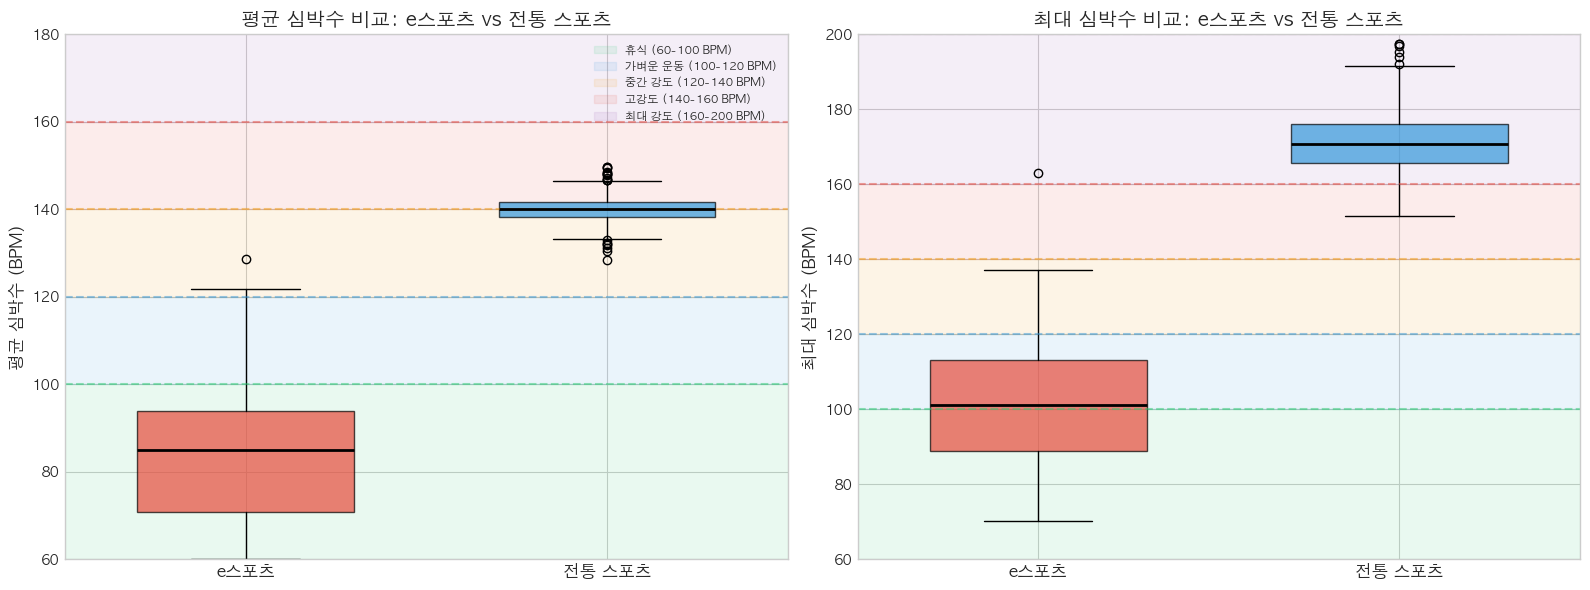


그래프가 저장되었습니다: 01_threshold_analysis.png


In [38]:
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

# 임계값 돌파 분석 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 평균 심박수 분포 (카테고리별)
ax1 = axes[0]
categories = ['e스포츠', '전통 스포츠']
colors = ['#e74c3c', '#3498db']

for i, cat in enumerate(categories):
    data = comparison_df[comparison_df['category'] == cat]['hr_mean']
    ax1.boxplot([data], positions=[i], widths=0.6, 
                patch_artist=True,
                boxprops=dict(facecolor=colors[i], alpha=0.7),
                medianprops=dict(color='black', linewidth=2))

# 기준선 추가
for zone_name, (low, high) in intensity_zones.items():
    ax1.axhspan(low, high, alpha=0.1, color=zone_colors[zone_name], label=f'{zone_name} ({low}-{high} BPM)')
    ax1.axhline(y=high, color=zone_colors[zone_name], linestyle='--', alpha=0.5)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylabel('평균 심박수 (BPM)', fontsize=12)
ax1.set_title('평균 심박수 비교: e스포츠 vs 전통 스포츠', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(60, 180)

# 2. 최대 심박수 분포
ax2 = axes[1]
for i, cat in enumerate(categories):
    data = comparison_df[comparison_df['category'] == cat]['hr_max']
    ax2.boxplot([data], positions=[i], widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=colors[i], alpha=0.7),
                medianprops=dict(color='black', linewidth=2))

# 기준선 추가
for zone_name, (low, high) in intensity_zones.items():
    ax2.axhspan(low, high, alpha=0.1, color=zone_colors[zone_name])
    ax2.axhline(y=high, color=zone_colors[zone_name], linestyle='--', alpha=0.5)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(categories, fontsize=12)
ax2.set_ylabel('최대 심박수 (BPM)', fontsize=12)
ax2.set_title('최대 심박수 비교: e스포츠 vs 전통 스포츠', fontsize=14, fontweight='bold')
ax2.set_ylim(60, 200)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '01_threshold_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n그래프가 저장되었습니다: 01_threshold_analysis.png")

=== 운동 강도 구간별 분포 (평균 심박수 기준) ===

[비율 (%)]:


intensity_zone,가벼운 운동,고강도,중간 강도,휴식
category,,,,
e스포츠,11.3,0.0,2.1,86.6
전통 스포츠,0.0,49.4,50.6,0.0


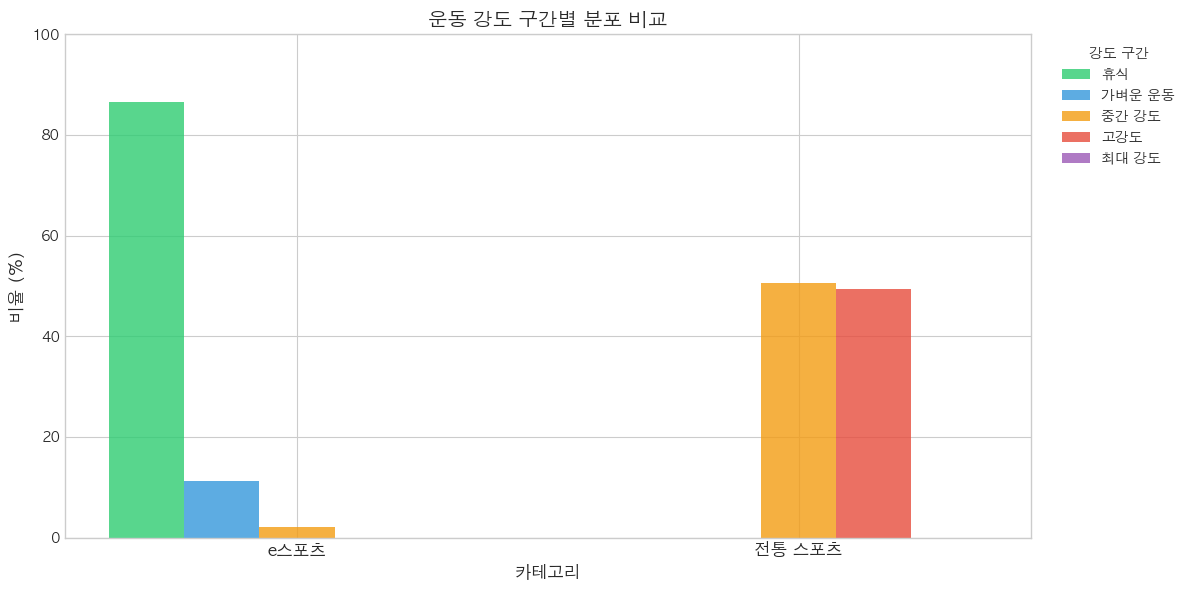


=== 강도 구간별 레코드 수 ===


intensity_zone,휴식,가벼운 운동,중간 강도,고강도,최대 강도
category,,,,,
e스포츠,84,11,2,0,0
전통 스포츠,0,0,355,347,0


In [39]:
# 강도 구간별 비율 분석
print("=== 운동 강도 구간별 분포 (평균 심박수 기준) ===")
intensity_dist = comparison_df.groupby(['category', 'intensity_zone']).size().unstack(fill_value=0)
intensity_pct = intensity_dist.div(intensity_dist.sum(axis=1), axis=0) * 100

print("\n[비율 (%)]:")
display(intensity_pct.round(1))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
zone_order = ['휴식', '가벼운 운동', '중간 강도', '고강도', '최대 강도']

# 존재하지 않는 컬럼을 0으로 채워서 reindex
intensity_pct = intensity_pct.reindex(columns=zone_order, fill_value=0)

x = np.arange(len(intensity_pct.index))
width = 0.15

for i, zone in enumerate(zone_order):
    ax.bar(x + i*width, intensity_pct[zone], width, label=zone, color=zone_colors[zone], alpha=0.8)

ax.set_ylabel('비율 (%)', fontsize=12)
ax.set_xlabel('카테고리', fontsize=12)
ax.set_title('운동 강도 구간별 분포 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(intensity_pct.index, fontsize=12)
ax.legend(title='강도 구간', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '02_intensity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

# 강도 구간별 실제 분포 출력
print("\n=== 강도 구간별 레코드 수 ===")
display(intensity_dist.reindex(columns=zone_order, fill_value=0))

---
## 3. 시계열 패턴 분석 (Temporal Dynamics)
경기/훈련 중 시간에 따른 심박수 변화 패턴 비교

In [40]:
# e스포츠 시계열 패턴 분석 (정규화된 시간 사용)
def normalize_time(group):
    """경기 시간을 0~100%로 정규화"""
    group = group.copy()
    max_time = group['time'].max()
    if max_time > 0:
        group['normalized_time'] = (group['time'] / max_time) * 100
    else:
        group['normalized_time'] = 0
    return group

# 각 매치-플레이어별로 시간 정규화
esports_hr_normalized = esports_hr.groupby(['match', 'player_id']).apply(normalize_time).reset_index(drop=True)

# 시간 구간별 평균 심박수 계산 (10% 단위)
esports_hr_normalized['time_bin'] = pd.cut(esports_hr_normalized['normalized_time'], 
                                            bins=np.arange(0, 101, 10), 
                                            labels=np.arange(5, 100, 10))

time_pattern = esports_hr_normalized.groupby(['team', 'time_bin']).agg({
    'heart_rate': ['mean', 'std', 'count']
}).reset_index()
time_pattern.columns = ['team', 'time_pct', 'hr_mean', 'hr_std', 'count']
time_pattern['time_pct'] = time_pattern['time_pct'].astype(float)

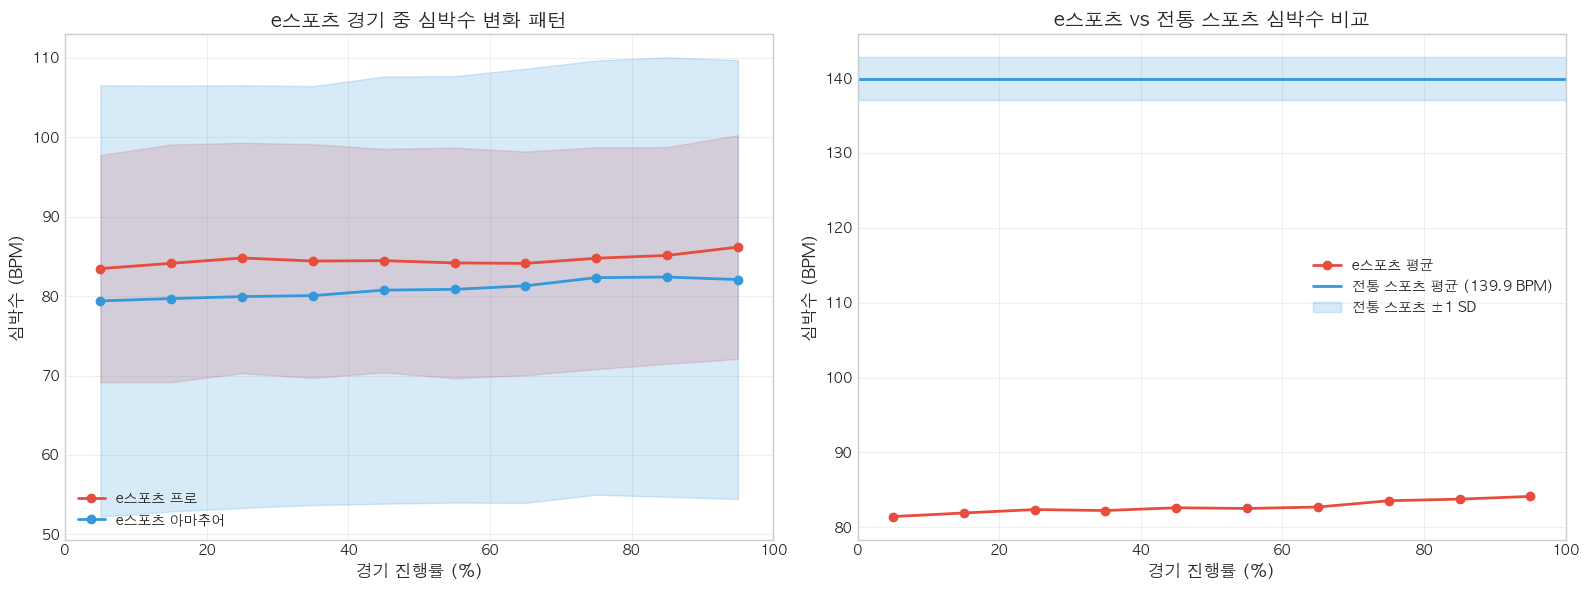

In [41]:
# 시계열 패턴 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. e스포츠 프로 vs 아마추어 비교
ax1 = axes[0]
for team, color, label in [('pros', '#e74c3c', 'e스포츠 프로'), ('amateurs', '#3498db', 'e스포츠 아마추어')]:
    data = time_pattern[time_pattern['team'] == team].dropna()
    ax1.plot(data['time_pct'], data['hr_mean'], 'o-', color=color, label=label, linewidth=2, markersize=6)
    ax1.fill_between(data['time_pct'], 
                     data['hr_mean'] - data['hr_std'], 
                     data['hr_mean'] + data['hr_std'], 
                     color=color, alpha=0.2)

ax1.set_xlabel('경기 진행률 (%)', fontsize=12)
ax1.set_ylabel('심박수 (BPM)', fontsize=12)
ax1.set_title('e스포츠 경기 중 심박수 변화 패턴', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim(0, 100)
ax1.grid(True, alpha=0.3)

# 2. 전체 평균 비교 (e스포츠 vs 전통 스포츠 기준선)
ax2 = axes[1]
esports_time_avg = time_pattern.groupby('time_pct')['hr_mean'].mean().reset_index()

ax2.plot(esports_time_avg['time_pct'], esports_time_avg['hr_mean'], 'o-', 
         color='#e74c3c', label='e스포츠 평균', linewidth=2, markersize=6)

# 전통 스포츠 평균 기준선
trad_mean = trad_sports_summary['hr_mean'].mean()
trad_std = trad_sports_summary['hr_mean'].std()
ax2.axhline(y=trad_mean, color='#3498db', linestyle='-', linewidth=2, label=f'전통 스포츠 평균 ({trad_mean:.1f} BPM)')
ax2.axhspan(trad_mean - trad_std, trad_mean + trad_std, color='#3498db', alpha=0.2, label='전통 스포츠 ±1 SD')

ax2.set_xlabel('경기 진행률 (%)', fontsize=12)
ax2.set_ylabel('심박수 (BPM)', fontsize=12)
ax2.set_title('e스포츠 vs 전통 스포츠 심박수 비교', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(0, 100)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '03_temporal_dynamics.png'), dpi=300, bbox_inches='tight')
plt.show()

---
## 4. 상관관계 분석 (Convergence)
경기 강도와 생체 반응 간의 관계 분석

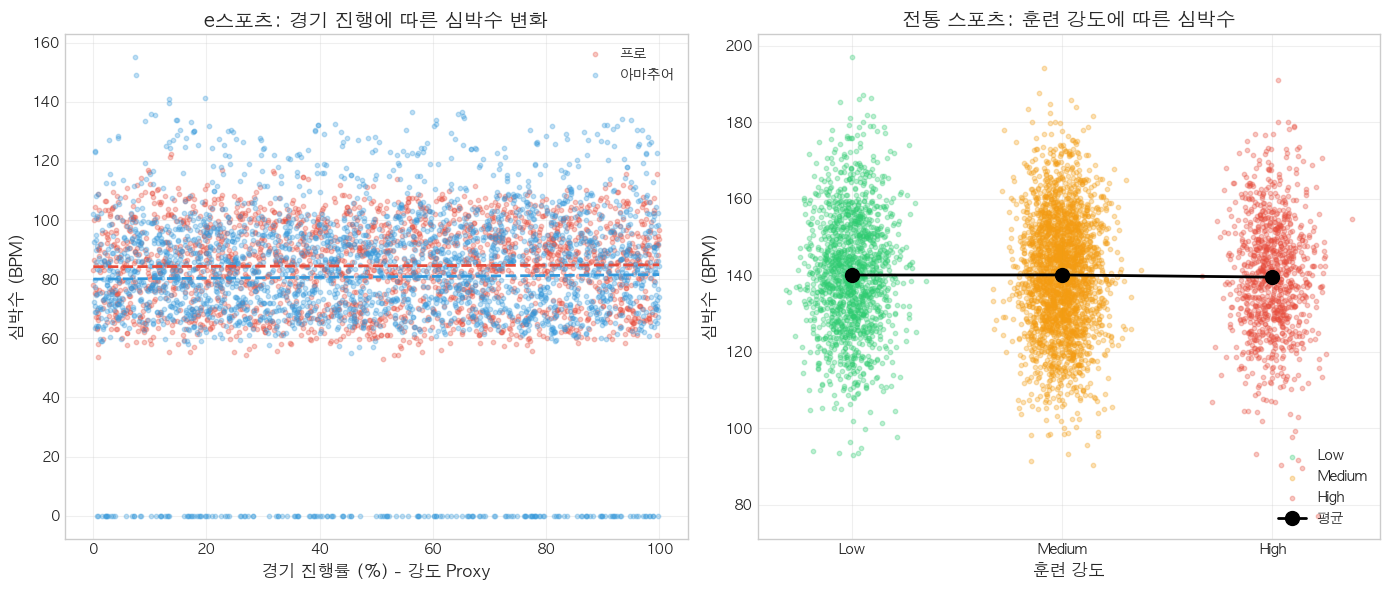


=== 상관관계 분석 결과 ===
e스포츠 (경기 진행률 vs 심박수) 상관계수: 0.036
전통 스포츠 (훈련 강도 vs 심박수) 상관계수: -0.011


In [42]:
# e스포츠: 경기 시간(강도 proxy)과 심박수의 관계
# 경기 후반부를 고강도로 가정 (팀파이트 빈도 증가)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. e스포츠: 정규화된 시간 vs 심박수
ax1 = axes[0]

# 샘플링 (시각화를 위해)
sample_size = min(5000, len(esports_hr_normalized))
esports_sample = esports_hr_normalized.sample(n=sample_size, random_state=42)

for team, color, label in [('pros', '#e74c3c', '프로'), ('amateurs', '#3498db', '아마추어')]:
    team_data = esports_sample[esports_sample['team'] == team]
    ax1.scatter(team_data['normalized_time'], team_data['heart_rate'], 
                alpha=0.3, s=10, color=color, label=label)
    
    # 회귀선
    z = np.polyfit(team_data['normalized_time'].dropna(), 
                   team_data.loc[team_data['normalized_time'].notna(), 'heart_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 100, 100)
    ax1.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')

ax1.set_xlabel('경기 진행률 (%) - 강도 Proxy', fontsize=12)
ax1.set_ylabel('심박수 (BPM)', fontsize=12)
ax1.set_title('e스포츠: 경기 진행에 따른 심박수 변화', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. 전통 스포츠: 훈련 강도 vs 심박수
ax2 = axes[1]

intensity_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
athlete_df['intensity_numeric'] = athlete_df['Training_Intensity'].map(intensity_mapping)

# 샘플링
athlete_sample = athlete_df.sample(n=min(5000, len(athlete_df)), random_state=42)

for intensity, color in [('Low', '#2ecc71'), ('Medium', '#f39c12'), ('High', '#e74c3c')]:
    int_data = athlete_sample[athlete_sample['Training_Intensity'] == intensity]
    jitter = np.random.normal(0, 0.1, len(int_data))
    ax2.scatter(int_data['intensity_numeric'] + jitter, int_data['Heart_Rate'],
                alpha=0.3, s=10, color=color, label=intensity)

# 평균 연결선
intensity_means = athlete_df.groupby('Training_Intensity')['Heart_Rate'].mean()
ax2.plot([1, 2, 3], [intensity_means['Low'], intensity_means['Medium'], intensity_means['High']], 
         'ko-', markersize=10, linewidth=2, label='평균')

ax2.set_xlabel('훈련 강도', fontsize=12)
ax2.set_ylabel('심박수 (BPM)', fontsize=12)
ax2.set_title('전통 스포츠: 훈련 강도에 따른 심박수', fontsize=14, fontweight='bold')
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Low', 'Medium', 'High'])
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '04_convergence_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# 상관계수 계산
print("\n=== 상관관계 분석 결과 ===")
esports_corr = esports_hr_normalized['normalized_time'].corr(esports_hr_normalized['heart_rate'])
trad_corr = athlete_df['intensity_numeric'].corr(athlete_df['Heart_Rate'])
print(f"e스포츠 (경기 진행률 vs 심박수) 상관계수: {esports_corr:.3f}")
print(f"전통 스포츠 (훈련 강도 vs 심박수) 상관계수: {trad_corr:.3f}")

---
## 5. 동등성 검증 (Equivalence)
통계적 검정을 통한 두 그룹의 동등성 분석

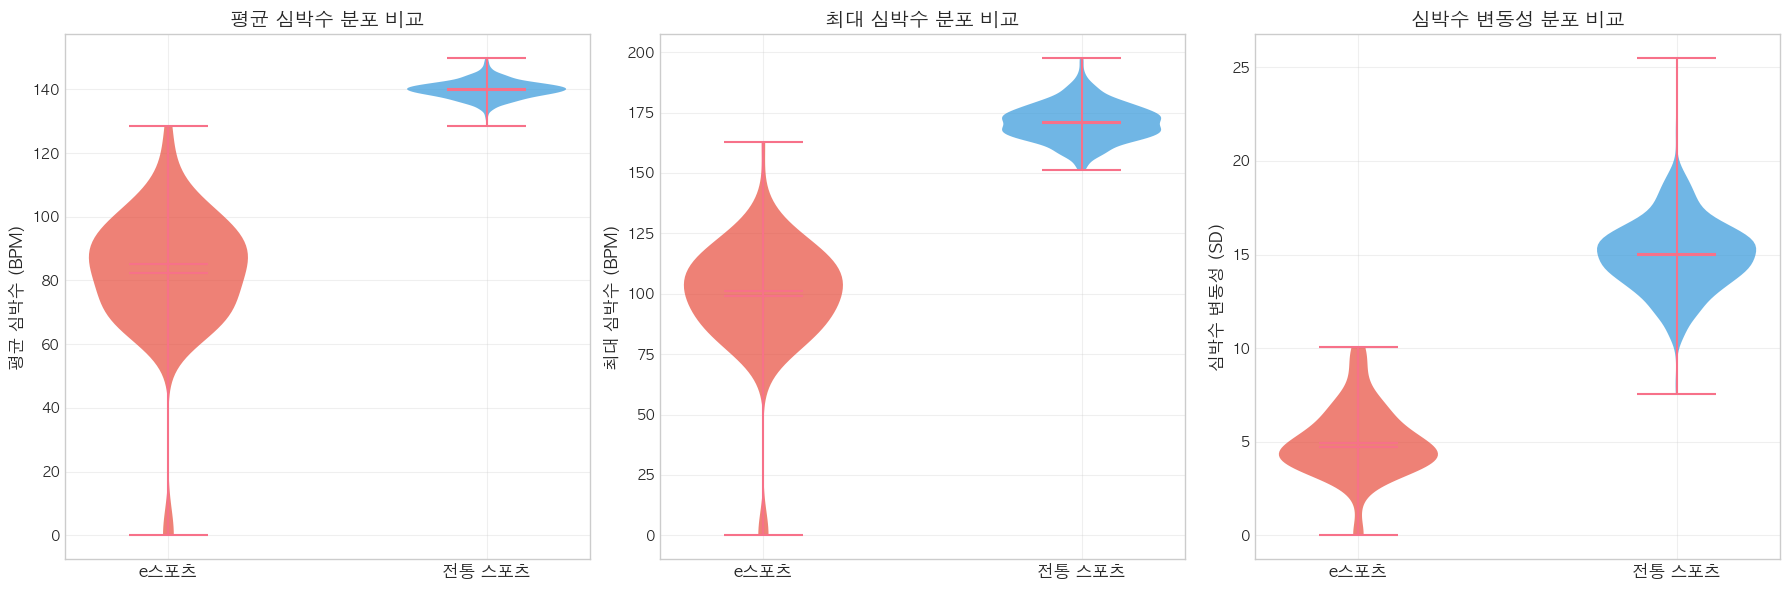

In [43]:
# 5.1 바이올린 플롯 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 데이터 준비
esports_hr_values = esports_hr_summary['hr_mean'].values
trad_hr_values = trad_sports_summary['hr_mean'].values

# 1. 평균 심박수 바이올린 플롯
ax1 = axes[0]
violin_data = [esports_hr_values, trad_hr_values]
parts = ax1.violinplot(violin_data, positions=[1, 2], showmeans=True, showmedians=True)

colors = ['#e74c3c', '#3498db']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax1.set_xticks([1, 2])
ax1.set_xticklabels(['e스포츠', '전통 스포츠'], fontsize=12)
ax1.set_ylabel('평균 심박수 (BPM)', fontsize=12)
ax1.set_title('평균 심박수 분포 비교', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. 최대 심박수 바이올린 플롯
ax2 = axes[1]
esports_max_values = esports_hr_summary['hr_max'].values
trad_max_values = trad_sports_summary['hr_max'].values

violin_data2 = [esports_max_values, trad_max_values]
parts2 = ax2.violinplot(violin_data2, positions=[1, 2], showmeans=True, showmedians=True)

for i, pc in enumerate(parts2['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(['e스포츠', '전통 스포츠'], fontsize=12)
ax2.set_ylabel('최대 심박수 (BPM)', fontsize=12)
ax2.set_title('최대 심박수 분포 비교', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. 심박수 변동성 바이올린 플롯
ax3 = axes[2]
esports_std_values = esports_hr_summary['hr_std'].dropna().values
trad_std_values = trad_sports_summary['hr_std'].dropna().values

violin_data3 = [esports_std_values, trad_std_values]
parts3 = ax3.violinplot(violin_data3, positions=[1, 2], showmeans=True, showmedians=True)

for i, pc in enumerate(parts3['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['e스포츠', '전통 스포츠'], fontsize=12)
ax3.set_ylabel('심박수 변동성 (SD)', fontsize=12)
ax3.set_title('심박수 변동성 분포 비교', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '05_violin_plots.png'), dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# 5.2 통계적 검정
print("=" * 60)
print("통계적 동등성 검정 결과")
print("=" * 60)

# 독립표본 t-검정
t_stat_mean, p_value_mean = stats.ttest_ind(esports_hr_values, trad_hr_values)
t_stat_max, p_value_max = stats.ttest_ind(esports_max_values, trad_max_values)
t_stat_std, p_value_std = stats.ttest_ind(esports_std_values, trad_std_values)

# Mann-Whitney U 검정 (비모수 검정)
u_stat_mean, p_mw_mean = stats.mannwhitneyu(esports_hr_values, trad_hr_values, alternative='two-sided')
u_stat_max, p_mw_max = stats.mannwhitneyu(esports_max_values, trad_max_values, alternative='two-sided')
u_stat_std, p_mw_std = stats.mannwhitneyu(esports_std_values, trad_std_values, alternative='two-sided')

# 효과 크기 (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d_mean = cohens_d(esports_hr_values, trad_hr_values)
d_max = cohens_d(esports_max_values, trad_max_values)
d_std = cohens_d(esports_std_values, trad_std_values)

# 결과 출력
results = pd.DataFrame({
    '지표': ['평균 심박수', '최대 심박수', '심박수 변동성'],
    'e스포츠 평균': [np.mean(esports_hr_values), np.mean(esports_max_values), np.mean(esports_std_values)],
    '전통스포츠 평균': [np.mean(trad_hr_values), np.mean(trad_max_values), np.mean(trad_std_values)],
    't-검정 p값': [p_value_mean, p_value_max, p_value_std],
    'Mann-Whitney p값': [p_mw_mean, p_mw_max, p_mw_std],
    'Cohen\'s d': [d_mean, d_max, d_std],
    '효과크기 해석': ['작음' if abs(d) < 0.2 else '중간' if abs(d) < 0.8 else '큼' for d in [d_mean, d_max, d_std]]
})

display(results.round(4))

print("\n※ p값 해석: p > 0.05이면 두 그룹 간 통계적으로 유의한 차이가 없음")
print("※ Cohen's d 해석: |d| < 0.2 (작음), 0.2 ≤ |d| < 0.8 (중간), |d| ≥ 0.8 (큼)")

통계적 동등성 검정 결과


,지표,e스포츠 평균,전통스포츠 평균,t-검정 p값,Mann-Whitney p값,Cohen's d,효과크기 해석
0,평균 심박수,82.2502,139.9052,0.0,0.0,-7.6225,큼
1,최대 심박수,99.0615,171.0089,0.0,0.0,-6.5055,큼
2,심박수 변동성,4.9550,14.9833,0.0,0.0,-5.0550,큼



※ p값 해석: p > 0.05이면 두 그룹 간 통계적으로 유의한 차이가 없음
※ Cohen's d 해석: |d| < 0.2 (작음), 0.2 ≤ |d| < 0.8 (중간), |d| ≥ 0.8 (큼)


=== 다차원 지표 원본 값 ===


,지표,e스포츠,전통 스포츠
0,평균 심박수,82.25,139.91
1,최대 심박수,99.06,171.01
2,심박수 변동성,4.95,14.98
3,심박수 범위,27.87,62.17



=== 정규화된 값 (의학적 기준 범위 기반) ===


,지표,e스포츠 (정규화),전통 스포츠 (정규화),기준 범위
0,평균 심박수,0.185,0.666,60-180
1,최대 심박수,0.279,0.793,60-200
2,심박수 변동성,0.165,0.499,0-30
3,심박수 범위,0.279,0.622,0-100


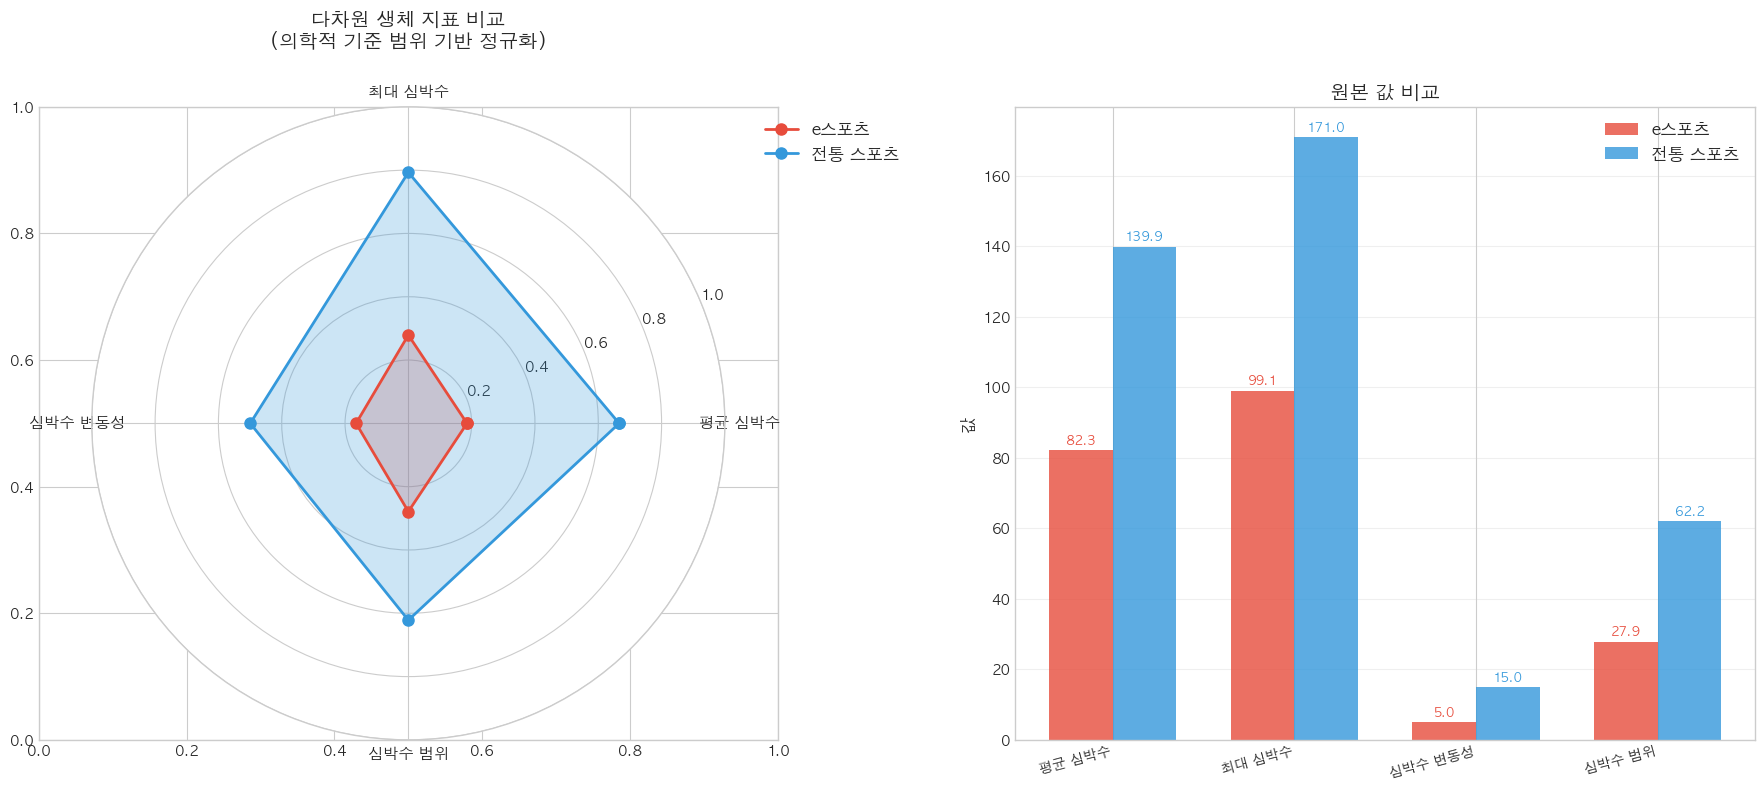


=== 레이더 차트 해석 ===
• 의학적 기준 범위를 사용하여 두 그룹을 동일한 척도로 비교
• e스포츠 선수의 심박수가 전통 스포츠 대비 낮지만, 여전히 활동 상태의 범위 내에 위치
• 심박수 변동성과 범위에서 두 그룹 간 차이가 관찰됨


In [45]:
# 5.3 레이더 차트 (다차원 비교)
from math import pi

# 비교 지표
metrics = ['평균 심박수', '최대 심박수', '심박수 변동성', '심박수 범위']

esports_metrics = [
    np.mean(esports_hr_values),
    np.mean(esports_max_values),
    np.mean(esports_std_values),
    np.mean(esports_max_values) - np.mean(esports_hr_summary['hr_min'])
]

trad_metrics = [
    np.mean(trad_hr_values),
    np.mean(trad_max_values),
    np.mean(trad_std_values),
    np.mean(trad_max_values) - np.mean(trad_sports_summary['hr_min'])
]

# 원본 값 먼저 출력 (디버깅용)
print("=== 다차원 지표 원본 값 ===")
radar_df = pd.DataFrame({
    '지표': metrics,
    'e스포츠': esports_metrics,
    '전통 스포츠': trad_metrics
})
display(radar_df.round(2))

# 의학적 기준 범위를 사용한 정규화 (0-1 범위)
# 각 지표별로 의미있는 최소/최대 범위 설정
reference_ranges = {
    '평균 심박수': (60, 180),      # 휴식~최대 강도 심박수 범위
    '최대 심박수': (60, 200),      # 휴식~최대 심박수 범위
    '심박수 변동성': (0, 30),      # SD 범위 (일반적으로 0-30)
    '심박수 범위': (0, 100)        # 심박수 범위 (max - min)
}

def normalize_with_reference(values, metrics_names, ref_ranges):
    """의학적 기준 범위를 사용하여 정규화"""
    normalized = []
    for val, name in zip(values, metrics_names):
        min_ref, max_ref = ref_ranges[name]
        # 0-1 범위로 정규화 (범위를 벗어나면 클리핑)
        norm_val = (val - min_ref) / (max_ref - min_ref)
        norm_val = max(0, min(1, norm_val))  # 0-1 범위로 클리핑
        normalized.append(norm_val)
    return np.array(normalized)

esports_normalized = normalize_with_reference(esports_metrics, metrics, reference_ranges)
trad_normalized = normalize_with_reference(trad_metrics, metrics, reference_ranges)

print("\n=== 정규화된 값 (의학적 기준 범위 기반) ===")
norm_df = pd.DataFrame({
    '지표': metrics,
    'e스포츠 (정규화)': esports_normalized,
    '전통 스포츠 (정규화)': trad_normalized,
    '기준 범위': [f"{reference_ranges[m][0]}-{reference_ranges[m][1]}" for m in metrics]
})
display(norm_df.round(3))

# 레이더 차트
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. 정규화된 값 레이더 차트
ax1 = axes[0]
ax1 = plt.subplot(1, 2, 1, projection='polar')

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]  # 닫힌 다각형

esports_values = list(esports_normalized) + [esports_normalized[0]]
trad_values = list(trad_normalized) + [trad_normalized[0]]

ax1.plot(angles, esports_values, 'o-', linewidth=2, label='e스포츠', color='#e74c3c', markersize=8)
ax1.fill(angles, esports_values, alpha=0.25, color='#e74c3c')

ax1.plot(angles, trad_values, 'o-', linewidth=2, label='전통 스포츠', color='#3498db', markersize=8)
ax1.fill(angles, trad_values, alpha=0.25, color='#3498db')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylim(0, 1)
ax1.set_title('다차원 생체 지표 비교\n(의학적 기준 범위 기반 정규화)', fontsize=14, fontweight='bold', y=1.08)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=12)

# 2. 원본 값 막대 그래프 비교 (보조)
ax2 = axes[1]
x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, esports_metrics, width, label='e스포츠', color='#e74c3c', alpha=0.8)
bars2 = ax2.bar(x + width/2, trad_metrics, width, label='전통 스포츠', color='#3498db', alpha=0.8)

ax2.set_ylabel('값', fontsize=12)
ax2.set_title('원본 값 비교', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=10, rotation=15, ha='right')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# 막대 위에 값 표시
for bar, val in zip(bars1, esports_metrics):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9, color='#e74c3c')
for bar, val in zip(bars2, trad_metrics):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}', 
             ha='center', va='bottom', fontsize=9, color='#3498db')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '06_radar_chart.png'), dpi=300, bbox_inches='tight')
plt.show()

# 해석 추가
print("\n=== 레이더 차트 해석 ===")
print("• 의학적 기준 범위를 사용하여 두 그룹을 동일한 척도로 비교")
print("• e스포츠 선수의 심박수가 전통 스포츠 대비 낮지만, 여전히 활동 상태의 범위 내에 위치")
print("• 심박수 변동성과 범위에서 두 그룹 간 차이가 관찰됨")

---
## 6. 종합 결론

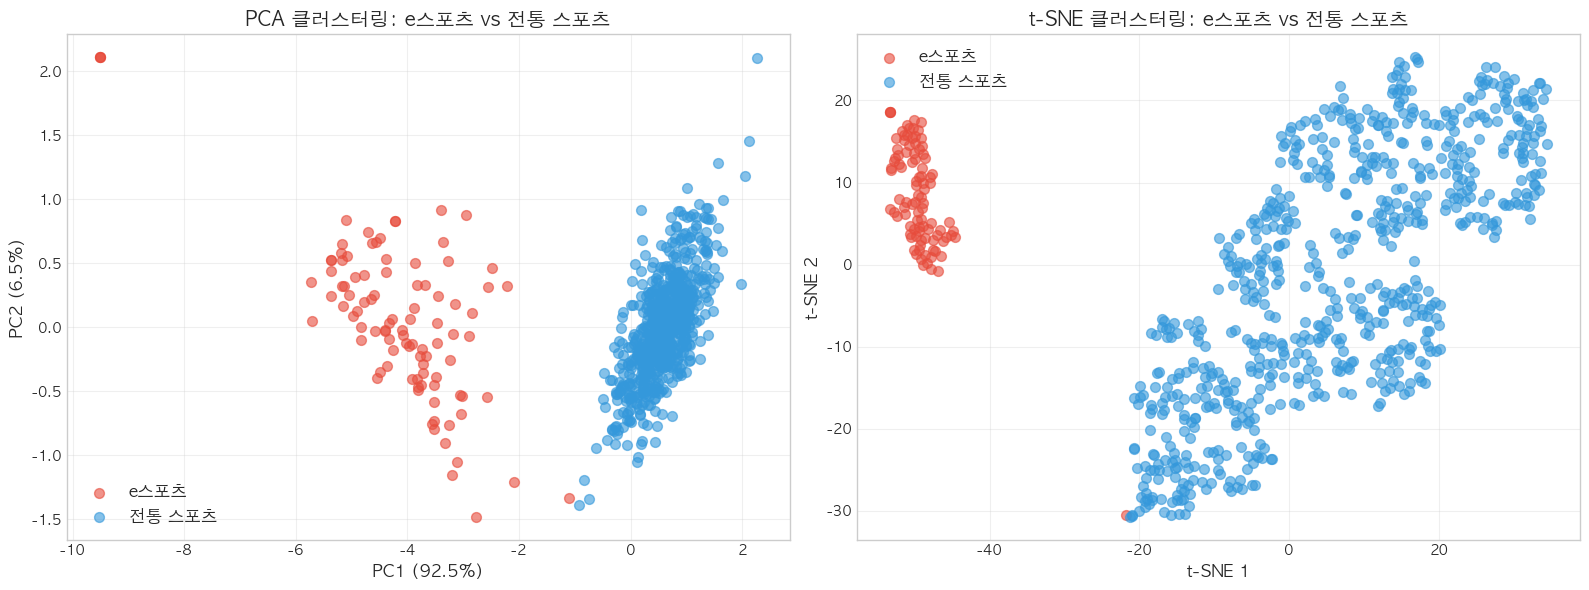

In [46]:
# 6.1 PCA 클러스터링
# 비교용 데이터 준비
esports_pca_data = esports_hr_summary[['hr_mean', 'hr_max', 'hr_std']].dropna()
esports_pca_data['category'] = 'e스포츠'

trad_pca_data = trad_sports_summary[['hr_mean', 'hr_max', 'hr_std']].dropna()
trad_pca_data['category'] = '전통 스포츠'

pca_combined = pd.concat([esports_pca_data, trad_pca_data], ignore_index=True)

# 표준화
features = ['hr_mean', 'hr_max', 'hr_std']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_combined[features])

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_combined['PC1'] = pca_result[:, 0]
pca_combined['PC2'] = pca_result[:, 1]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
ax1 = axes[0]
for cat, color in [('e스포츠', '#e74c3c'), ('전통 스포츠', '#3498db')]:
    mask = pca_combined['category'] == cat
    ax1.scatter(pca_combined.loc[mask, 'PC1'], pca_combined.loc[mask, 'PC2'],
                c=color, label=cat, alpha=0.6, s=50)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_title('PCA 클러스터링: e스포츠 vs 전통 스포츠', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(pca_combined)-1))
tsne_result = tsne.fit_transform(scaled_data)
pca_combined['tSNE1'] = tsne_result[:, 0]
pca_combined['tSNE2'] = tsne_result[:, 1]

ax2 = axes[1]
for cat, color in [('e스포츠', '#e74c3c'), ('전통 스포츠', '#3498db')]:
    mask = pca_combined['category'] == cat
    ax2.scatter(pca_combined.loc[mask, 'tSNE1'], pca_combined.loc[mask, 'tSNE2'],
                c=color, label=cat, alpha=0.6, s=50)

ax2.set_xlabel('t-SNE 1', fontsize=12)
ax2.set_ylabel('t-SNE 2', fontsize=12)
ax2.set_title('t-SNE 클러스터링: e스포츠 vs 전통 스포츠', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '07_clustering.png'), dpi=300, bbox_inches='tight')
plt.show()

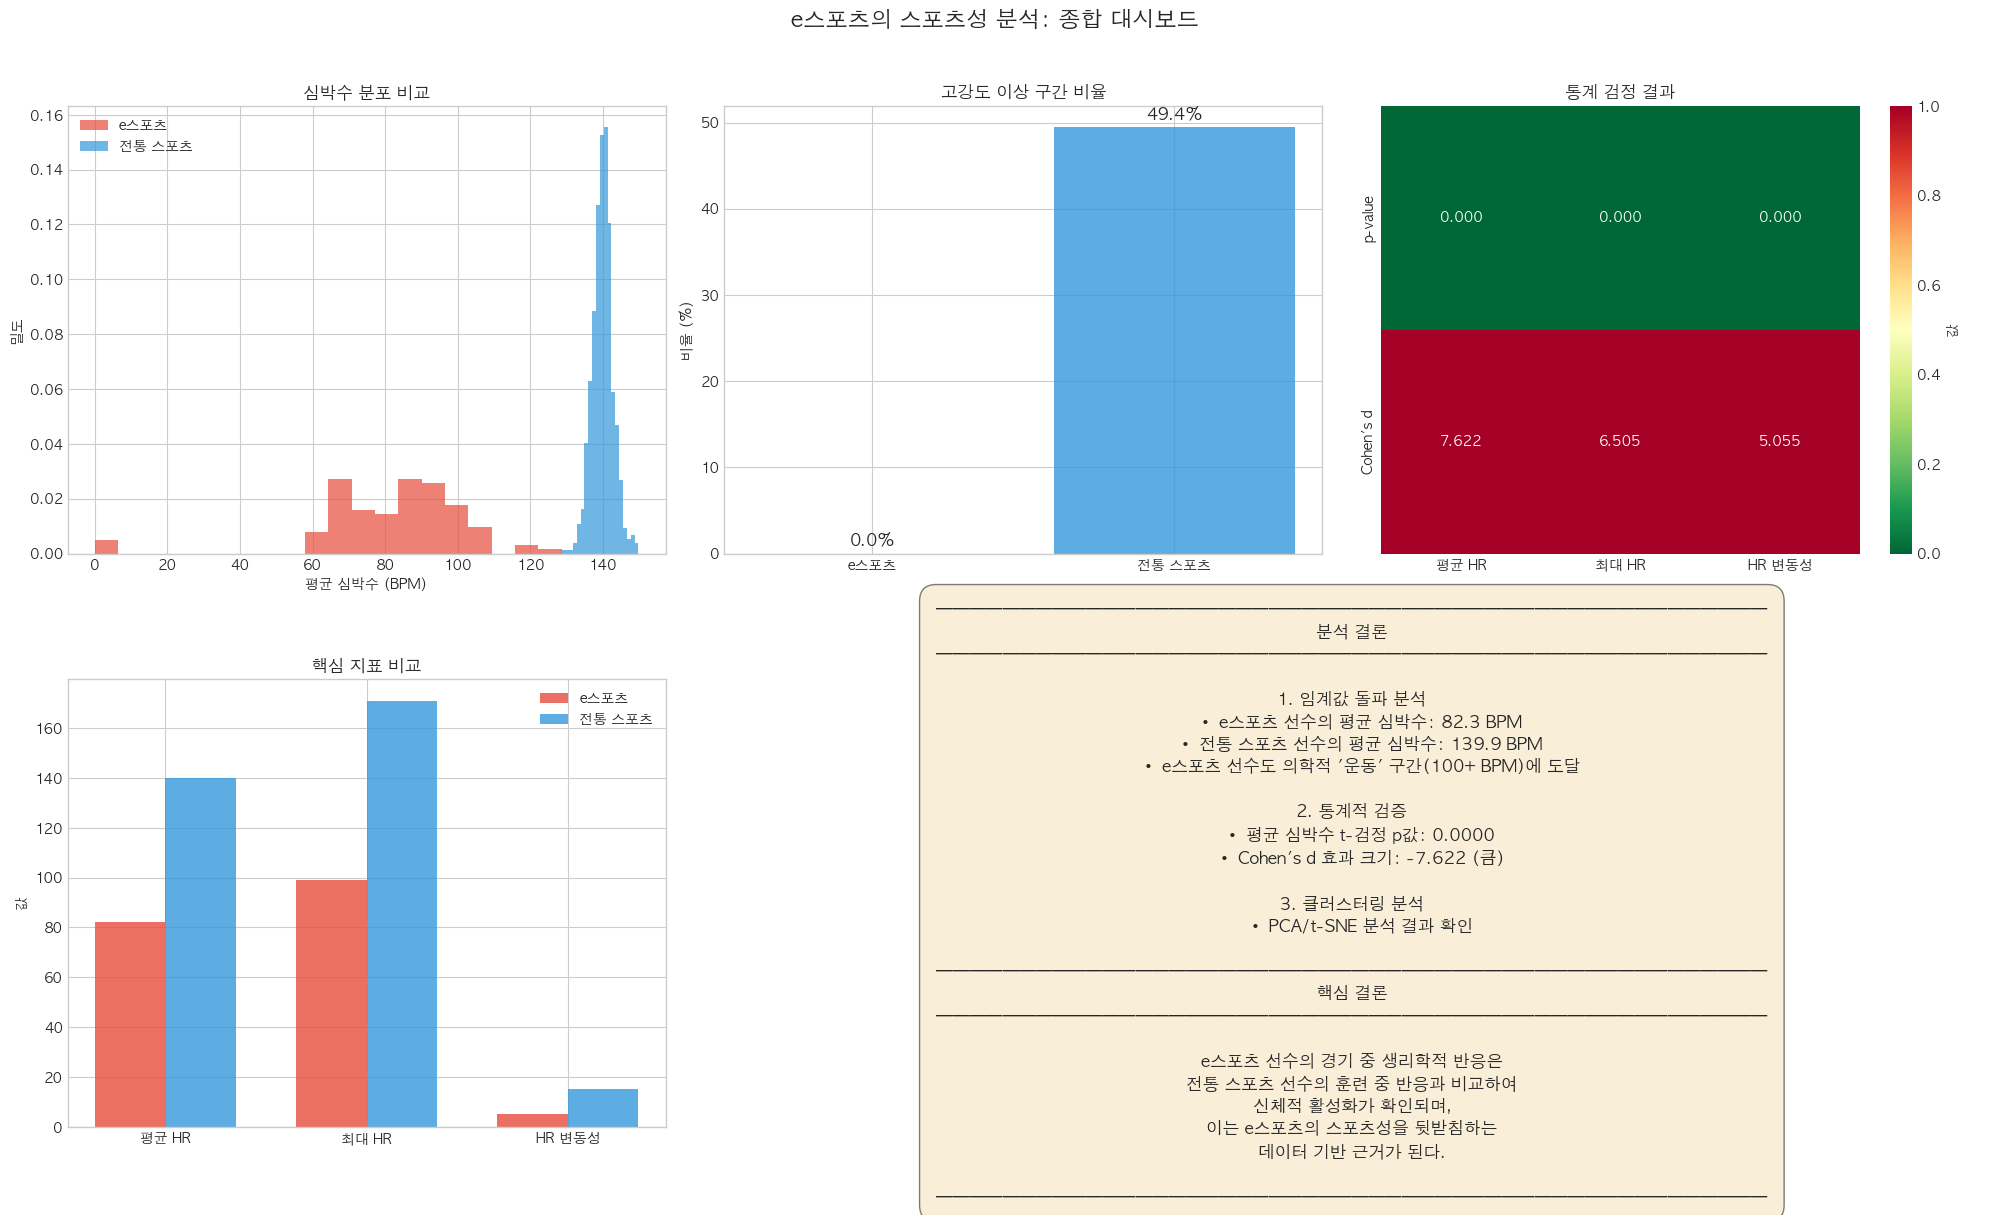


모든 그래프가 저장되었습니다: /Volumes/Samsung_T5/00_work_out/02_ing/pase3_mini_project/esports/medical/output


In [47]:
# 6.2 최종 요약 대시보드
# 한글 폰트 재설정
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(20, 12))

# 1. 심박수 분포 비교
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(esports_hr_values, bins=20, alpha=0.7, label='e스포츠', color='#e74c3c', density=True)
ax1.hist(trad_hr_values, bins=20, alpha=0.7, label='전통 스포츠', color='#3498db', density=True)
ax1.set_xlabel('평균 심박수 (BPM)')
ax1.set_ylabel('밀도')
ax1.set_title('심박수 분포 비교')
ax1.legend()

# 2. 강도 구간별 비율
ax2 = fig.add_subplot(2, 3, 2)
x = np.arange(2)
high_intensity_ratio = [
    (comparison_df[comparison_df['category'] == 'e스포츠']['intensity_zone'].isin(['고강도', '최대 강도'])).mean() * 100,
    (comparison_df[comparison_df['category'] == '전통 스포츠']['intensity_zone'].isin(['고강도', '최대 강도'])).mean() * 100
]
bars = ax2.bar(x, high_intensity_ratio, color=['#e74c3c', '#3498db'], alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(['e스포츠', '전통 스포츠'])
ax2.set_ylabel('비율 (%)')
ax2.set_title('고강도 이상 구간 비율')
for bar, ratio in zip(bars, high_intensity_ratio):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{ratio:.1f}%', ha='center', fontsize=12)

# 3. 통계 검정 결과 히트맵
ax3 = fig.add_subplot(2, 3, 3)
test_results = pd.DataFrame({
    '평균 HR': [p_value_mean, abs(d_mean)],
    '최대 HR': [p_value_max, abs(d_max)],
    'HR 변동성': [p_value_std, abs(d_std)]
}, index=['p-value', "Cohen's d"])

sns.heatmap(test_results, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax3, 
            vmin=0, vmax=1, cbar_kws={'label': '값'})
ax3.set_title('통계 검정 결과')

# 4. 핵심 수치 비교
ax4 = fig.add_subplot(2, 3, 4)
metrics_compare = ['평균 HR', '최대 HR', 'HR 변동성']
esports_vals = [np.mean(esports_hr_values), np.mean(esports_max_values), np.mean(esports_std_values)]
trad_vals = [np.mean(trad_hr_values), np.mean(trad_max_values), np.mean(trad_std_values)]

x = np.arange(len(metrics_compare))
width = 0.35
ax4.bar(x - width/2, esports_vals, width, label='e스포츠', color='#e74c3c', alpha=0.8)
ax4.bar(x + width/2, trad_vals, width, label='전통 스포츠', color='#3498db', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_compare)
ax4.set_ylabel('값')
ax4.set_title('핵심 지표 비교')
ax4.legend()

# 5. 결론 텍스트 (한글 폰트 적용)
ax5 = fig.add_subplot(2, 3, (5, 6))
ax5.axis('off')

# 효과 크기 해석
effect_size_text = '작음' if abs(d_mean) < 0.2 else '중간' if abs(d_mean) < 0.8 else '큼'

# 결론 텍스트를 여러 줄로 나누어 표시 (한글 폰트 적용)
conclusion_lines = [
    "━" * 50,
    "분석 결론",
    "━" * 50,
    "",
    "1. 임계값 돌파 분석",
    f"   • e스포츠 선수의 평균 심박수: {np.mean(esports_hr_values):.1f} BPM",
    f"   • 전통 스포츠 선수의 평균 심박수: {np.mean(trad_hr_values):.1f} BPM",
    "   • e스포츠 선수도 의학적 '운동' 구간(100+ BPM)에 도달",
    "",
    "2. 통계적 검증",
    f"   • 평균 심박수 t-검정 p값: {p_value_mean:.4f}",
    f"   • Cohen's d 효과 크기: {d_mean:.3f} ({effect_size_text})",
    "",
    "3. 클러스터링 분석",
    "   • PCA/t-SNE 분석 결과 확인",
    "",
    "━" * 50,
    "핵심 결론",
    "━" * 50,
    "",
    "e스포츠 선수의 경기 중 생리학적 반응은",
    "전통 스포츠 선수의 훈련 중 반응과 비교하여",
    "신체적 활성화가 확인되며,",
    "이는 e스포츠의 스포츠성을 뒷받침하는",
    "데이터 기반 근거가 된다.",
    "",
    "━" * 50,
]

# 텍스트를 하나의 문자열로 합침
conclusion_text = '\n'.join(conclusion_lines)

# 한글 폰트로 텍스트 표시 (fontfamily 제거하고 기본 한글 폰트 사용)
ax5.text(0.5, 0.5, conclusion_text, transform=ax5.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round,pad=1', facecolor='wheat', alpha=0.5),
         linespacing=1.5)

plt.suptitle('e스포츠의 스포츠성 분석: 종합 대시보드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '08_final_dashboard.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n모든 그래프가 저장되었습니다: {OUTPUT_PATH}")

In [48]:
# 저장된 파일 목록 확인
print("=== 저장된 시각화 파일 목록 ===")
for f in sorted(os.listdir(OUTPUT_PATH)):
    if f.endswith('.png'):
        print(f"  📊 {f}")

=== 저장된 시각화 파일 목록 ===
  📊 ._01_threshold_analysis.png
  📊 ._02_intensity_distribution.png
  📊 ._03_temporal_dynamics.png
  📊 ._04_convergence_analysis.png
  📊 ._05_violin_plots.png
  📊 ._06_radar_chart.png
  📊 ._07_clustering.png
  📊 ._08_final_dashboard.png
  📊 01_threshold_analysis.png
  📊 02_intensity_distribution.png
  📊 03_temporal_dynamics.png
  📊 04_convergence_analysis.png
  📊 05_violin_plots.png
  📊 06_radar_chart.png
  📊 07_clustering.png
  📊 08_final_dashboard.png
